# Project 2 — Data Classification Using AI
**DecodeLabs AI Internship — Supervised Learning**


We will teach a computer to look at a flower's measurements and guess which
of 3 species it is — **without writing a single "if" rule ourselves**. Instead,
we show the computer 120 examples, and it learns the pattern on its own.

This notebook follows the exact pipeline from the training material:

| INPUT | PROCESS | OUTPUT |
|---|---|---|
| Iris Domain + Feature Scaling | Train-Test Split + KNN Algorithm | Confusion Matrix + F1 Score |



In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

sns.set_theme(style="whitegrid")
print("Libraries loaded.")

Libraries loaded.


## Step 1 — "Raw Material: The Iris Benchmark"


- **150 samples** (flowers), perfectly balanced: 50 of each type
- **3 classes** (species): Setosa, Versicolor, Virginica
- **4 measurements per flower** ("features"): sepal length, sepal width, petal length, petal width — all in cm



In [11]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Samples : {df.shape[0]}")
print(f"Features: {df.shape[1] - 1}")
print(f"Classes : {list(iris.target_names)}")
df.head()

Samples : 150
Features: 4
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


**A simple picture of the data.**
We plot 2 of the 4 measurements (petal length vs petal width) and color each
dot by its true species.
 the 3 species naturally form 3 separate groups.

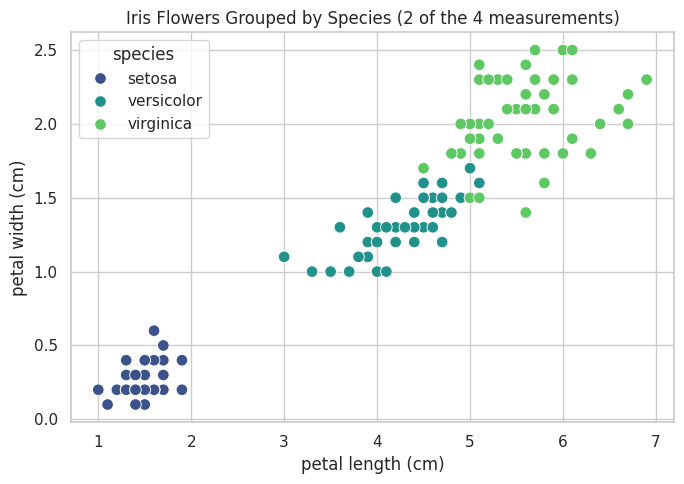

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=df, x="petal length (cm)", y="petal width (cm)",
    hue="species", palette="viridis", s=70
)
plt.title("Iris Flowers Grouped by Species (2 of the 4 measurements)")
plt.tight_layout()
plt.savefig("01_dataset_overview.png", dpi=150)
plt.show()

## Step 2 — "The Gatekeeper Rule: Scaling"  *(INPUT stage)*

The 4 measurements are not on the same scale (e.g. petal length ranges wider
than petal width). If we leave them as-is, the algorithm we use next (KNN,
which measures *distance* between points) would unfairly let the
larger-range feature dominate.

**Fix:** `StandardScaler` rescales every feature so it has **mean = 0** and
**variance = 1**. After this, all 4 measurements are treated fairly.

In [13]:
X = iris.data
y = iris.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling — first row:", X[0])
print("After scaling  — first row:", np.round(X_scaled[0], 2))

Before scaling — first row: [5.1 3.5 1.4 0.2]
After scaling  — first row: [-0.9   1.02 -1.34 -1.32]


## Step 3 — "Structural Integrity: The Split"  *(PROCESS stage)*

We must never test the model on data it already saw during training : that
would be like grading a student on questions they already had the answers
to. So we split the 150 flowers into two separate groups:

- **Training set (70% = 105 flowers)** — the model learns from these
- **Test set (30% = 45 flowers)** — used only to check the model afterwards, completely unseen during training

We also **shuffle** the data before splitting, so the split isn't biased by
how the data happened to be ordered.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    shuffle=True,
    stratify=y,
    random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 105
Testing samples : 45


## Step 4 — "The Algorithm: K-Nearest Neighbors"

**The idea in one sentence:** *similar things exist close together.*

To classify a new flower, KNN looks at its **K closest neighbors** (already-
known flowers) and takes a majority vote. If most of its nearest neighbors
are "Versicolor", KNN guesses "Versicolor" too.

The only real decision we have to make is: **how many neighbors (K) should
it look at?** That's the next step.

## Step 5 — "Tuning the Engine: Choosing K"

Picking K isn't arbitrary , it's a trade-off:

- **K too small (like K=1):** the model just copies its single nearest
  neighbor. Very sensitive to noise → **overfitting**.
- **K too large (like K=100):** the model looks at almost everyone, so its
  answer becomes too generic → **underfitting**.
- **The sweet spot ("the elbow"):** the K where the error rate is lowest.

**How we test each K fairly:** instead of judging each K on a single lucky/
unlucky 30-sample test split, we use **5-fold cross-validation** : we split
the training data 5 different ways and average the error. This gives a much
more reliable, smoother curve.

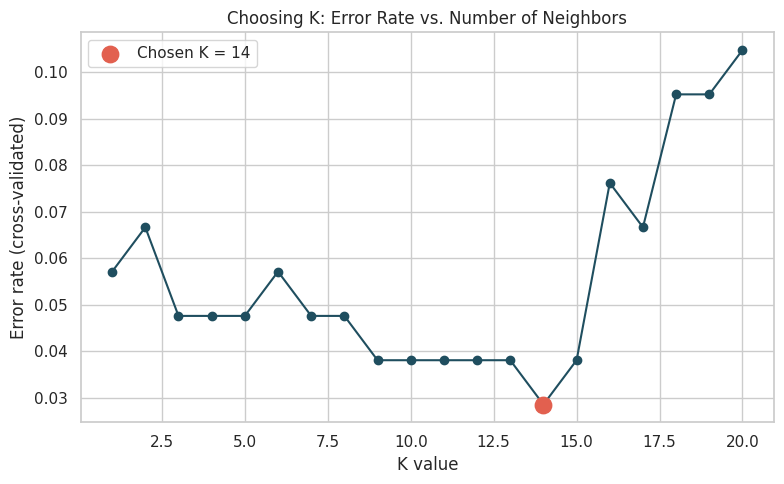

Chosen K = 14  (lowest average error = 0.029)


In [15]:
k_range = range(1, 21)
error_rates = []

for k in k_range:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    error_rates.append(1 - scores.mean())

k_list = list(k_range)
safe_candidates = [(k, err) for k, err in zip(k_list, error_rates) if k >= 3]
best_k, best_err = min(safe_candidates, key=lambda pair: pair[1])

plt.figure(figsize=(8, 5))
plt.plot(k_list, error_rates, marker="o", color="#1f4e5f")
plt.scatter([best_k], [best_err], color="#e2604f", s=140, zorder=5, label=f"Chosen K = {best_k}")
plt.title('Choosing K: Error Rate vs. Number of Neighbors')
plt.xlabel("K value")
plt.ylabel("Error rate (cross-validated)")
plt.legend()
plt.tight_layout()
plt.savefig("02_choosing_k.png", dpi=150)
plt.show()

print(f"Chosen K = {best_k}  (lowest average error = {best_err:.3f})")

## Step 6 — "The Workflow: Scikit-Learn"

Now we train the real model, using the exact 3-line pattern from the slide:

```python
model = KNeighborsClassifier(n_neighbors=5)   # INSTANTIATE — build the frame
model.fit(X_train, y_train)                   # FIT — memorize the map
predictions = model.predict(X_test)           # PREDICT — apply the logic
```

We use our chosen K from Step 5 instead of a fixed guess.

In [16]:
model = KNeighborsClassifier(n_neighbors=best_k)   # INSTANTIATE
model.fit(X_train, y_train)                        # FIT
predictions = model.predict(X_test)                # PREDICT

print(f"Model trained with K={best_k}. Predictions made on {len(X_test)} unseen flowers.")

Model trained with K=14. Predictions made on 45 unseen flowers.


## Step 7 — "Output Validation"

> *"In imbalanced data, accuracy is a lie. We must look deeper."*

A single accuracy number can hide problems (e.g. a model that always
guesses the majority class can still score "high"). So besides accuracy, we
check two more honest tools:

1. **Confusion Matrix** — shows exactly which species got confused with which
2. **F1 Score** — a balanced score combining Precision and Recall (the
   harmonic mean), so a model can't "cheat" by being good at only one of them

In [17]:
acc = accuracy_score(y_test, predictions)
f1 = f1_score(y_test, predictions, average="macro")

print(f"Accuracy : {acc:.1%}")
print(f"F1 Score : {f1:.1%}")
print()
print(classification_report(y_test, predictions, target_names=iris.target_names))

Accuracy : 95.6%
F1 Score : 95.5%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      1.00      0.94        15
   virginica       1.00      0.87      0.93        15

    accuracy                           0.96        45
   macro avg       0.96      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



### "The Diagnostic Tool: Confusion Matrix"



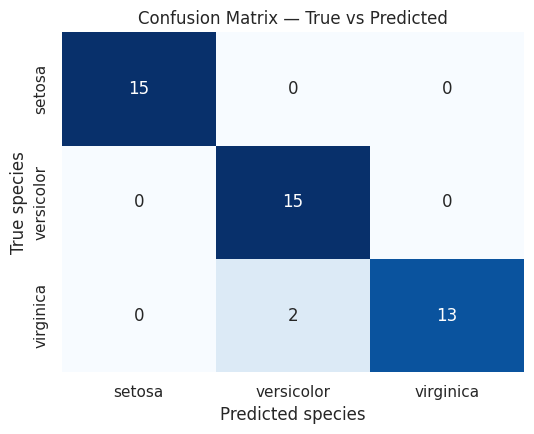

In [18]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names, yticklabels=iris.target_names, cbar=False)
plt.title("Confusion Matrix — True vs Predicted")
plt.xlabel("Predicted species")
plt.ylabel("True species")
plt.tight_layout()
plt.savefig("03_confusion_matrix.png", dpi=150)
plt.show()